# Analysis — Scientific Literature RAG for Document QA

Reads the committed result JSON files under `results/` and reproduces the tables and
the core findings from the README. **No experiment is run here** — this notebook is a
reader, so it cannot invent a number that the pipeline did not produce.

Run the pipeline first (see README §14) if `results/` is empty.

In [1]:
import json
from pathlib import Path

import pandas as pd

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
RESULTS = ROOT / "results"

def load(rel):
    p = RESULTS / rel
    if not p.exists():
        raise FileNotFoundError(f"{p} missing — run the pipeline first (README §14)")
    return json.loads(p.read_text())

pd.set_option("display.width", 140)
pd.set_option("display.max_columns", 40)

## 1. Retrieval comparison

Six configurations, identical questions and judgements.

In [2]:
ret = load("retrieval/retrieval_results.json")
rows = []
for name, r in ret["systems"].items():
    m = r["metrics"]
    rows.append({
        "system": name,
        "hit@1": m["hit@1"], "hit@5": m["hit@5"], "hit@10": m["hit@10"],
        "recall@10": m["recall@10"], "MRR@10": m["mrr@10"], "nDCG@10": m["ndcg@10"],
        "ms/query": r["timings"]["ms_per_query"],
    })
retrieval_df = pd.DataFrame(rows).set_index("system").round(3)
print(f"test questions: {ret['n_questions']}   corpus chunks: {ret['corpus']['n_chunks']}")
retrieval_df

test questions: 437   corpus chunks: 4844


,hit@1,hit@5,hit@10,recall@10,MRR@10,nDCG@10,ms/query
system,,,,,,,
bm25,0.588,0.760,0.810,0.797,0.660,0.689,1.725
dense,0.394,0.588,0.698,0.674,0.477,0.513,1.692
hybrid_rrf,0.503,0.744,0.817,0.804,0.604,0.646,3.353
bm25_rerank,0.714,0.856,0.886,0.876,0.771,0.788,223.192
dense_rerank,0.648,0.760,0.783,0.768,0.692,0.699,265.779
hybrid_rrf_rerank,0.725,0.860,0.892,0.878,0.779,0.791,279.641


### Significance vs BM25

Paired bootstrap (10,000 resamples). Pairing matters: both systems see exactly the
same questions, so pairing removes question difficulty as a variance source.

In [3]:
sig_rows = []
for comparison, metrics in ret["significance_vs_bm25"].items():
    for metric, s in metrics.items():
        if metric not in ("hit@1", "hit@5", "mrr@10"):
            continue
        sig_rows.append({
            "comparison": comparison, "metric": metric,
            "delta": round(s["mean_delta"], 4),
            "ci95": f"[{s['ci95_low']:+.4f}, {s['ci95_high']:+.4f}]",
            "p": round(s["p_value"], 4),
            "significant": s["significant_at_0.05"],
        })
pd.DataFrame(sig_rows).set_index(["comparison", "metric"])

delta                ci95       p  significant
comparison                       metric                                                 
dense_vs_bm25                    hit@1  -0.1945  [-0.2494, -0.1419]  0.0000         True
                                 hit@5  -0.1716  [-0.2220, -0.1213]  0.0000         True
                                 mrr@10 -0.1824  [-0.2291, -0.1382]  0.0000         True
hybrid_rrf_vs_bm25               hit@1  -0.0847  [-0.1281, -0.0434]  0.0002         True
                                 hit@5  -0.0160  [-0.0503, +0.0160]  0.3654        False
                                 mrr@10 -0.0561  [-0.0888, -0.0244]  0.0004         True
bm25_rerank_vs_bm25              hit@1   0.1259  [+0.0847, +0.1670]  0.0000         True
                                 hit@5   0.0961  [+0.0664, +0.1259]  0.0000         True
                                 mrr@10  0.1111  [+0.0810, +0.1414]  0.0000         True
dense_rerank_vs_bm25             hit@1   0.0595  [+0.0092, +0.1098]  0.0222         True
                                 hit@5   0.0000  [-0.0435, +0.0435]  1.0000        False
                                 mrr@10  0.0325  [-0.0098, +0.0739]  0.1310        False
hybrid_rrf_rerank_vs_bm25        hit@1   0.1373  [+0.0938, +0.1808]  0.0000         True
                                 hit@5   0.1007  [+0.0686, +0.1350]  0.0000         True
                                 mrr@10  0.1192  [+0.0869, +0.1514]  0.0000         True
hybrid_rrf_rerank_vs_bm25_rerank hit@1   0.0114  [+0.0000, +0.0229]  0.0686        False
                                 hit@5   0.0046  [-0.0137, +0.0229]  0.7188        False
                                 mrr@10  0.0081  [-0.0029, +0.0204]  0.1624        False
hybrid_rrf_rerank_vs_hybrid_rrf  hit@1   0.2220  [+0.1762, +0.2677]  0.0000         True
                                 hit@5   0.1167  [+0.0801, +0.1533]  0.0000         True
                                 mrr@10  0.1754  [+0.1418, +0.2104]  0.0000         True

**Findings.** Dense loses to BM25 on this biomedical corpus; RRF fusion *hurts*
MRR relative to BM25 alone; the cross-encoder supplies nearly all of the gain, and
hybrid fusion adds nothing measurable once it is present.

## 2. End-to-end RAG, with floor and ceiling controls

In [4]:
rag = load("rag/rag_results.json")
order = ["closed_book", "rag_bm25", "rag_hybrid_rerank", "rag_hybrid_lora",
         "oracle_context", "oracle_context_lora"]
rag_df = pd.DataFrame([
    {"system": s,
     "EM": rag["systems"][s]["exact_match"],
     "F1": rag["systems"][s]["f1"],
     "answer_in_context": rag["systems"][s]["answer_in_context"],
     "gold_retrieved": rag["systems"][s]["gold_chunk_retrieved"],
     "groundedness_proxy": rag["systems"][s]["groundedness_proxy"],
     "ms/query": rag["systems"][s]["latency_ms_mean"]}
    for s in order if s in rag["systems"]
]).set_index("system").round(2)
rag_df

,EM,F1,answer_in_context,gold_retrieved,groundedness_proxy,ms/query
system,,,,,,
closed_book,0.00,4.55,0.00,0.00,0.00,43.16
rag_bm25,23.80,46.91,75.06,75.97,100.00,124.60
rag_hybrid_rerank,26.09,49.58,84.67,86.04,100.00,898.85
rag_hybrid_lora,35.47,59.46,84.67,86.04,100.00,1020.96
oracle_context,30.43,60.70,99.31,100.00,99.51,37.95
oracle_context_lora,43.48,73.19,99.31,100.00,99.75,26.21


### The decomposition

Reading the 2×2 of {base, LoRA} reader × {retrieved, oracle} context tells you which
component to fix — something no single aggregate score can do.

In [5]:
S = rag["systems"]
grid = pd.DataFrame(
    [[S["rag_hybrid_rerank"]["f1"], S["oracle_context"]["f1"]],
     [S["rag_hybrid_lora"]["f1"],   S["oracle_context_lora"]["f1"]]],
    index=["base reader", "LoRA reader"],
    columns=["retrieved context", "oracle context"],
).round(2)
grid["retrieval cost (F1)"] = (grid["retrieved context"] - grid["oracle context"]).round(2)
grid.loc["fine-tuning gain"] = (grid.loc["LoRA reader"] - grid.loc["base reader"]).round(2)

print(grid.to_string())
print()
print(f"Reader error even with perfect context : {100 - S['oracle_context_lora']['f1']:.2f} F1")
print(f"Retrieval error with the LoRA reader   : "
      f"{S['oracle_context_lora']['f1'] - S['rag_hybrid_lora']['f1']:.2f} F1")
print("\n-> the reader is the larger bottleneck, by roughly 2x")

                  retrieved context  oracle context  retrieval cost (F1)
base reader                   49.58           60.70               -11.12
LoRA reader                   59.46           73.19               -13.73
fine-tuning gain               9.88           12.49                -2.61

Reader error even with perfect context : 26.81 F1
Retrieval error with the LoRA reader   : 13.73 F1

-> the reader is the larger bottleneck, by roughly 2x


## 3. Fine-tuning: parameter efficiency and training curve

In [6]:
ft = load("finetuning/finetuning_results.json")
p = ft["parameters"]["with_lora"]
print(f"base model          : {ft['base_model']}")
print(f"total parameters    : {p['total_parameters']:,}")
print(f"trainable parameters: {p['trainable_parameters']:,}  ({p['trainable_percent']}%)")
print(f"training time       : {ft['training']['seconds']}s "
      f"({ft['training']['minutes']} min) on {ft['device']}, {ft['training']['steps']} steps")

m = ft["metrics"]
pd.DataFrame([
    {"model": "base (SQuAD2, zero-shot)", **{f"{sp} {k}": m["base"][sp][k]
     for sp in ("validation", "test") for k in ("exact_match", "f1")}},
    {"model": "LoRA fine-tuned", **{f"{sp} {k}": m["finetuned"][sp][k]
     for sp in ("validation", "test") for k in ("exact_match", "f1")}},
]).set_index("model").round(2)

base model          : deepset/roberta-base-squad2
total parameters    : 124,647,940
trainable parameters: 591,362  (0.4744%)
training time       : 598.5s (9.97 min) on mps, 432 steps


,validation exact_match,validation f1,test exact_match,test f1
model,,,,
"base (SQuAD2, zero-shot)",32.53,62.91,30.65,61.1
LoRA fine-tuned,41.69,74.36,43.55,73.5


 epoch  val_loss
   1.0  1.976730
   2.0  1.904998
   3.0  1.913948

Validation loss flattens then ticks up at epoch 3 -> mild overfitting begins;
this is why training was not extended.


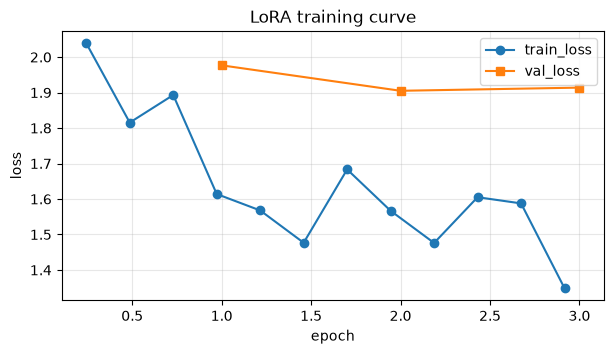

In [7]:
history = ft["training"]["log_history"]
train = pd.DataFrame([{"epoch": h["epoch"], "train_loss": h["loss"]}
                      for h in history if "loss" in h and "eval_loss" not in h])
val = pd.DataFrame([{"epoch": h["epoch"], "val_loss": h["eval_loss"]}
                    for h in history if "eval_loss" in h])
ax = train.plot(x="epoch", y="train_loss", marker="o", figsize=(7, 3.5))
val.plot(x="epoch", y="val_loss", marker="s", ax=ax)
ax.set_ylabel("loss"); ax.set_title("LoRA training curve"); ax.grid(alpha=0.3)
print(val.to_string(index=False))
print("\nValidation loss flattens then ticks up at epoch 3 -> mild overfitting begins;")
print("this is why training was not extended.")

## 4. Ablations

In [8]:
chunking = load("retrieval/ablation_chunking.json")["cells"]
pd.DataFrame([
    {"chunk_size": c["chunk_size"], "n_chunks": c["chunk_stats"]["n_chunks"],
     **{f"{s} hit@5": round(c["systems"][s]["metrics"]["hit@5"], 3)
        for s in ("bm25", "dense", "hybrid_rrf")}}
    for c in sorted(chunking.values(), key=lambda x: x["chunk_size"])
]).set_index("chunk_size")

,n_chunks,bm25 hit@5,dense hit@5,hybrid_rrf hit@5
chunk_size,,,,
500,9935,0.741,0.625,0.732
1000,4844,0.760,0.588,0.744
2000,2433,0.794,0.558,0.719


In [9]:
emb = load("retrieval/ablation_embedding.json")["cells"]
pd.DataFrame([
    {"model": name,
     **{k: round(c["systems"]["dense"]["metrics"][k], 3) for k in ("hit@1", "hit@5", "mrr@10")}}
    for name, c in emb.items()
]).set_index("model")

,hit@1,hit@5,mrr@10
model,,,
bge-small-en-v1.5,0.394,0.588,0.477
all-MiniLM-L6-v2,0.263,0.481,0.352


Dense retrieval degrades as chunks grow — a bi-encoder compresses the whole
passage into one vector, so more text means more dilution. BM25 improves, being
unaffected by length once IDF is accounted for. `bge-small` beats `MiniLM`, but both
lose to BM25: the deficit is domain mismatch, not a weak model choice.

*Caveat:* `hit@k` is not strictly comparable across chunk sizes, since the retrieval
unit itself changes. The BM25-vs-dense direction is the trustworthy signal.

## 5. Error analysis

In [10]:
ea = load("error_analysis/error_analysis.json")
report = ea["report"]
print(f"system: {ea['system']}")
print(f"exactly correct: {report['n_correct']}/{report['n_questions']} "
      f"({100 * report['n_correct'] / report['n_questions']:.1f}%)\n")
pd.DataFrame([
    {"category": c, "count": n, "share of failures %": report["failure_share"][c]}
    for c, n in report["counts"].items() if c != "correct" and n > 0
]).set_index("category").sort_values("count", ascending=False)

system: rag_hybrid_lora
exactly correct: 155/437 (35.5%)



,count,share of failures %
category,,
partial_match,193,68.4
reranker_demotion,37,13.1
reader_miss,20,7.1
retrieval_miss,19,6.7
context_truncated,12,4.3
chunk_boundary,1,0.4


In [11]:
print("Mean F1 by gold answer length:")
display(pd.DataFrame(ea["by_answer_length"]).T)
print("\nThe cross-encoder demotes the gold chunk in "
      f"{report['counts']['reranker_demotion']} cases — vs "
      f"{report['counts']['retrieval_miss']} where the first stage misses it entirely.")
print("The component with the largest retrieval gain is also a top failure source.")

Mean F1 by gold answer length:


,n,mean_f1
1-20 chars,77.0,71.32
21-60,122.0,67.42
61-150,142.0,57.61
150+,96.0,42.58



The cross-encoder demotes the gold chunk in 37 cases — vs 19 where the first stage misses it entirely.
The component with the largest retrieval gain is also a top failure source.


## 6. Latency

In [12]:
b = load("benchmarks/benchmark_results.json")
print(f"device: {b['environment']['device']}   chunks: {b['environment']['n_chunks']}   "
      f"RSS after models: {b['memory']['rss_after_models_mb']} MB\n")
pd.DataFrame({**b["components"], **b["end_to_end"]}).T[
    ["p50_ms", "p95_ms", "p99_ms", "mean_ms"]]

device: mps   chunks: 4844   RSS after models: 660.3 MB



,p50_ms,p95_ms,p99_ms,mean_ms
retrieval_bm25,2.22,4.80,6.73,2.44
retrieval_dense,7.45,13.37,15.76,8.93
retrieval_hybrid,10.84,16.93,17.20,11.30
rerank_cross_encoder,239.86,271.56,404.08,243.86
reader_extractive,113.51,165.55,166.56,133.70
rag_bm25_no_rerank,127.16,173.87,180.59,130.77
rag_hybrid_rerank,431.98,494.64,618.71,434.90


In [13]:
tp = pd.DataFrame(b["throughput"]).T.set_index("batch_size")[["queries_per_second", "ms_per_query"]]
print(tp.to_string())
rr = b["components"]["rerank_cross_encoder"]["p50_ms"]
hy = b["components"]["retrieval_hybrid"]["p50_ms"]
print(f"\nReranking is {100 * rr / (rr + hy):.0f}% of retrieval latency "
      f"({rr:.0f} ms vs {hy:.0f} ms) and buys +0.126 hit@1.")

            queries_per_second  ms_per_query
batch_size                                  
1.0                       1.85        541.70
4.0                       1.92        520.63
8.0                       2.05        488.77
16.0                      1.85        540.26

Reranking is 96% of retrieval latency (240 ms vs 11 ms) and buys +0.126 hit@1.
